# HFSS 데이터 기반 등가회로 추출 (6.78 MHz 단일 주파수)

**모델:** Tx, Rx 각각 `(L + R1) // C // R2`,  두 코일은 상호 인덕턴스 `M`(결합계수 k)로 결합.

| 소자 | 물리적 의미 | 추출 근거 |
|---|---|---|
| `L`  | 인덕턴스 | HFSS Z 정밀값에서 (C 보정 포함) |
| `R1` (직렬) | 도체손 (skin/proximity) | Field_Loss의 **구리손** 비율 |
| `C`  | 자기용량 (self-capacitance) | sweep의 자기공진(SRF) — *근사* |
| `R2` (병렬) | 유전체손(FR4) + 코어손(ferrite) | Field_Loss의 **비구리손** 비율 |

**데이터 출처**
- `COIL.csv` : 6.78 MHz 정밀 단일 해석 → **권위 있는 Z값** (L, R1, R2, M)
- `COIL_SWEEP.csv` : 공진 추정용 (C). 6.78 MHz ≪ SRF 이므로 C 영향 ~3%, 근사로 충분
- `Field_Loss_1000V.csv` : 재질별 손실 분해 → R1:R2 분배비

**추출 원리 (단일 주파수에서 4개 미지수 푸는 법)**  
단일 주파수 복소 Z는 실수식 2개뿐이라 L,R1,C,R2 (4개)를 결정 못 함. 따라서:
1. `C` ← SRF에서 고정,  2. `R1:R2 손실비` ← Field_Loss에서 고정,  3. 나머지 `L,R1,R2` ← Z를 정확히 일치 (닫힌 해).

## 1. 데이터 로드

In [1]:
import csv, math
import numpy as np
import matplotlib.pyplot as plt

f0 = 6.78e6                 # 목표 주파수 [Hz]
w  = 2*math.pi*f0

def load(fn):
    rows = list(csv.reader(open(fn)))
    return rows[0], rows[1:]

# --- 권위 있는 단일점 Z (COIL.csv) ---
h, d = load('COIL.csv')
row = d[0]
def Zc(re, im):
    return float(row[h.index(re)]) + 1j*float(row[h.index(im)])
Z11 = Zc('re(Zt(1_T1,1_T1)) []', 'im(Zt(1_T1,1_T1)) []')   # Tx self
Z22 = Zc('re(Zt(2_T1,2_T1)) []', 'im(Zt(2_T1,2_T1)) []')   # Rx self
Z21 = Zc('re(Zt(2_T1,1_T1)) []', 'im(Zt(2_T1,1_T1)) []')   # mutual
print(f'Z11 (Tx) = {Z11.real:.4f} {Z11.imag:+.3f}j   |Z|={abs(Z11):.1f}  Q={Z11.imag/Z11.real:.0f}')
print(f'Z22 (Rx) = {Z22.real:.4f} {Z22.imag:+.3f}j   |Z|={abs(Z22):.1f}  Q={Z22.imag/Z22.real:.0f}')
print(f'Z21 (M ) = {Z21.real:.5f} {Z21.imag:+.4f}j')

Z11 (Tx) = 0.0936 +100.620j   |Z|=100.6  Q=1075
Z22 (Rx) = 0.0574 +106.896j   |Z|=106.9  Q=1861
Z21 (M ) = 0.00103 +2.0575j


## 2. C 추출 (sweep의 자기공진)

`C = 1 / ((2πf_SRF)^2 · L)`. SRF는 im(Z)가 0을 지나는 점, L은 저주파 인덕턴스.  
※ sweep은 공진 정밀도가 낮으므로 C는 근사값. 6.78 MHz에서 C의 리액턴스 기여는 약 (f0/f_SRF)^2 ≈ 3% 수준.

In [2]:
hs, ds = load('COIL_SWEEP.csv')
F = hs.index('Freq [MHz]')

def srf_and_L(imN):
    j = hs.index(imN); prev = None; Llow = None
    for r in ds:
        fr = float(r[F])*1e6; X = float(r[j])
        if Llow is None and fr >= 0.5e6:
            Llow = X/(2*math.pi*fr)          # 저주파 인덕턴스
        if prev and prev[1] > 0 and X < 0:    # 부호 반전 = 공진
            f1, x1 = prev
            return f1 + (fr-f1)*(x1/(x1-X)), Llow
        prev = (fr, X)
    return None, Llow

srf_tx, Llow_tx = srf_and_L('im(Zt(1_T1,1_T1)) []')
srf_rx, Llow_rx = srf_and_L('im(Zt(2_T1,2_T1)) []')
C_tx = 1/((2*math.pi*srf_tx)**2 * Llow_tx)
C_rx = 1/((2*math.pi*srf_rx)**2 * Llow_rx)
print(f'Tx: SRF={srf_tx/1e6:.1f} MHz  Llow={Llow_tx*1e6:.3f} uH  -> C={C_tx*1e12:.2f} pF')
print(f'Rx: SRF={srf_rx/1e6:.1f} MHz  Llow={Llow_rx*1e6:.3f} uH  -> C={C_rx*1e12:.2f} pF')

Tx: SRF=44.8 MHz  Llow=2.309 uH  -> C=5.47 pF
Rx: SRF=29.2 MHz  Llow=2.379 uH  -> C=12.48 pF


## 3. R1:R2 손실 분배비 (Field_Loss)

`R1`(직렬) = 도체(구리)손,  `R2`(병렬) = 유전체(FR4)+코어(ferrite)손.  
코일별로 `tx_*`, `rx_*` 손실을 합산해 구리손 비율 `r = P_cu / P_total` 산출. (k≈0.02로 결합이 약해 상호 유도손은 무시)

In [3]:
hl, dl = load('Field_Loss_1000V.csv'); lr = dl[0]
def L_(name): return float(lr[hl.index(name)])

cu_tx  = L_('loss_W_tx_ssw_coil_ssw_copper []')
die_tx = (L_('loss_W_tx_ssw_coil_pcb_1_fr4 []') + L_('loss_W_tx_ssw_coil_pcb_2_fr4 []')
          + L_('loss_W_tx_mull_ferrite_sheet []')   + L_('loss_W_tx_mull_ferrite_sheet_1 []')
          + L_('loss_W_tx_mull_ferrite_sheet_2 []') + L_('loss_W_tx_mull_ferrite_sheet_3 []'))
cu_rx  = L_('loss_W_rx_ssw_coil_ssw_copper []')
die_rx = L_('loss_W_rx_ssw_coil_pcb_1_fr4 []') + L_('loss_W_rx_ssw_coil_pcb_2_fr4 []')

r_tx = cu_tx/(cu_tx+die_tx)
r_rx = cu_rx/(cu_rx+die_rx)
print(f'Tx: 구리손={cu_tx:.4f}W  비구리손={die_tx:.4f}W  -> 구리비율 r={r_tx:.3f}')
print(f'Rx: 구리손={cu_rx:.4f}W  비구리손={die_rx:.4f}W  -> 구리비율 r={r_rx:.3f}')

Tx: 구리손=0.1049W  비구리손=0.0449W  -> 구리비율 r=0.700
Rx: 구리손=0.0571W  비구리손=0.0202W  -> 구리비율 r=0.738


## 4. 등가회로 추출 (닫힌 해)

어드미턴스 `Y = 1/Z = G + jB`,  `Y_model = jωC + 1/R2 + 1/(R1+jωL)`.  
C 고정, 손실비 r 고정 하에 Re/Im 일치 → 닫힌 해:

```
a  = ωC − B
L  = a / ( ω·((rG)² + a²) )
R1 = ωL·rG / a
R2 = 1 / ( G·(1−r) )
```

In [4]:
def extract(Z, C, r):
    Y = 1/Z; G, B = Y.real, Y.imag
    a  = w*C - B
    rG = r*G
    L  = a / (w*((rG)**2 + a**2))
    R1 = w*L*rG / a
    R2 = 1.0 / (G*(1-r))
    return L, R1, C, R2

def Zmodel(L, R1, C, R2):
    Y = 1j*w*C + 1/R2 + 1/(R1 + 1j*w*L)
    return 1/Y

L_tx, R1_tx, C_tx, R2_tx = extract(Z11, C_tx, r_tx)
L_rx, R1_rx, C_rx, R2_rx = extract(Z22, C_rx, r_rx)

# 상호 결합
M = Z21.imag / w
k = M / math.sqrt(L_tx * L_rx)

print(f'{"":4} {"L[uH]":>8} {"R1[mohm]":>9} {"C[pF]":>7} {"R2[kohm]":>9}')
print(f'{"Tx":4} {L_tx*1e6:8.3f} {R1_tx*1e3:9.2f} {C_tx*1e12:7.2f} {R2_tx/1e3:9.1f}')
print(f'{"Rx":4} {L_rx*1e6:8.3f} {R1_rx*1e3:9.2f} {C_rx*1e12:7.2f} {R2_rx/1e3:9.1f}')
print(f'\nM = {M*1e6:.4f} uH   k = {k:.4f}   (R_mutual = {Z21.real*1e3:.3f} mohm, 무시 가능)')

        L[uH]  R1[mohm]   C[pF]  R2[kohm]
Tx      2.308     62.59    5.47     360.9
Rx      2.374     37.98   12.48     760.5

M = 0.0483 uH   k = 0.0206   (R_mutual = 1.030 mohm, 무시 가능)


## 5. 검증 — 모델이 HFSS Z를 재현하는지

In [5]:
for nm, Z, p in [('Tx', Z11, (L_tx,R1_tx,C_tx,R2_tx)), ('Rx', Z22, (L_rx,R1_rx,C_rx,R2_rx))]:
    Zr = Zmodel(*p)
    err = abs(Zr-Z)/abs(Z)*100
    print(f'{nm}: target {Z.real:.4f}{Z.imag:+.3f}j   model {Zr.real:.4f}{Zr.imag:+.3f}j   err {err:.2e}%')

Tx: target 0.0936+100.620j   model 0.0936+100.620j   err 4.24e-14%
Rx: target 0.0574+106.896j   model 0.0574+106.896j   err 1.33e-14%


## 6. LTspice 소자값

각 코일을 노드 사이에 `R1`–`L` 직렬 가지, 그와 병렬로 `C`, `R2`. 두 인덕터를 `K L_tx L_rx {k}`로 결합.

In [6]:
def fmt(L,R1,C,R2):
    return (f'L={L*1e6:.3f}uH  R1(series)={R1*1e3:.2f}mohm  '
            f'C={C*1e12:.2f}pF  R2(parallel)={R2/1e3:.1f}kohm')
print('Tx :', fmt(L_tx,R1_tx,C_tx,R2_tx))
print('Rx :', fmt(L_rx,R1_rx,C_rx,R2_rx))
print(f'K  : k = {k:.4f}   (M = {M*1e6:.4f} uH)')

netlist = f'''* HFSS 등가회로 @ {f0/1e6:.2f} MHz  (각 코일: (R1+L)//C//R2)
* ---- Tx ----
R1t N1  Na {R1_tx:.4g}
Ltx Na 0  {L_tx:.4g}
Ctx N1 0  {C_tx:.4g}
R2t N1 0  {R2_tx:.4g}
* ---- Rx ----
R1r N2 Nb {R1_rx:.4g}
Lrx Nb 0  {L_rx:.4g}
Crx N2 0  {C_rx:.4g}
R2r N2 0  {R2_rx:.4g}
* ---- coupling ----
K1 Ltx Lrx {k:.4f}
'''
print('\n'+netlist)
open('equiv_circuit_6p78MHz.cir','w').write(netlist)
print('-> equiv_circuit_6p78MHz.cir 저장됨')

Tx : L=2.308uH  R1(series)=62.59mohm  C=5.47pF  R2(parallel)=360.9kohm
Rx : L=2.374uH  R1(series)=37.98mohm  C=12.48pF  R2(parallel)=760.5kohm
K  : k = 0.0206   (M = 0.0483 uH)

* HFSS 등가회로 @ 6.78 MHz  (각 코일: (R1+L)//C//R2)
* ---- Tx ----
R1t N1  Na 0.06259
Ltx Na 0  2.308e-06
Ctx N1 0  5.475e-12
R2t N1 0  3.609e+05
* ---- Rx ----
R1r N2 Nb 0.03798
Lrx Nb 0  2.374e-06
Crx N2 0  1.248e-11
R2r N2 0  7.605e+05
* ---- coupling ----
K1 Ltx Lrx 0.0206

-> equiv_circuit_6p78MHz.cir 저장됨


## 7. 참고 — 모델 vs sweep 전 대역 비교

단일 주파수(6.78 MHz)에서 맞춘 모델이므로 그 점에서만 일치 보장. 전 대역은 R이 주파수 종속이라 어긋나는 게 정상 (광대역 필요 시 R(f) 도입).

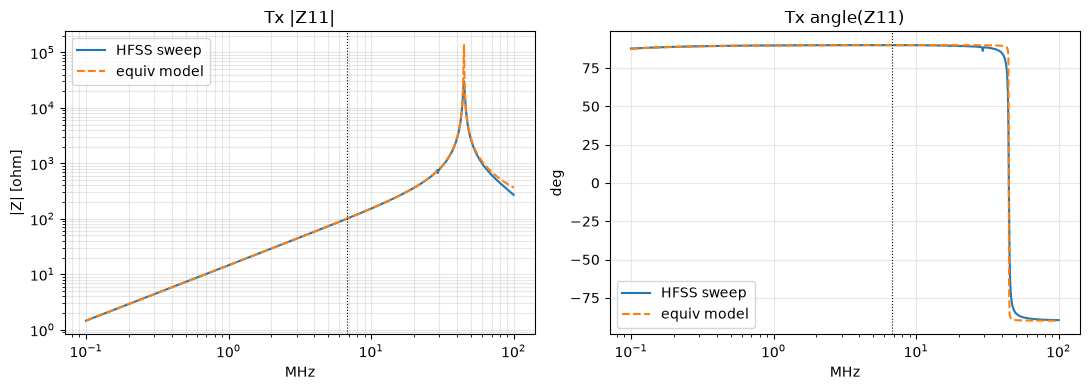

In [7]:
fr = np.array([float(r[F])*1e6 for r in ds])
reS = np.array([float(r[hs.index('re(Zt(1_T1,1_T1)) []')]) for r in ds])
imS = np.array([float(r[hs.index('im(Zt(1_T1,1_T1)) []')]) for r in ds])
Zs = reS + 1j*imS
ww = 2*np.pi*fr
Zm = 1/(1j*ww*C_tx + 1/R2_tx + 1/(R1_tx + 1j*ww*L_tx))

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].loglog(fr/1e6, np.abs(Zs), label='HFSS sweep')
ax[0].loglog(fr/1e6, np.abs(Zm), '--', label='equiv model')
ax[0].axvline(f0/1e6, color='k', ls=':', lw=0.8)
ax[0].set_title('Tx |Z11|'); ax[0].set_xlabel('MHz'); ax[0].set_ylabel('|Z| [ohm]'); ax[0].legend(); ax[0].grid(True, which='both', alpha=.3)
ax[1].semilogx(fr/1e6, np.angle(Zs, deg=True), label='HFSS sweep')
ax[1].semilogx(fr/1e6, np.angle(Zm, deg=True), '--', label='equiv model')
ax[1].axvline(f0/1e6, color='k', ls=':', lw=0.8)
ax[1].set_title('Tx angle(Z11)'); ax[1].set_xlabel('MHz'); ax[1].set_ylabel('deg'); ax[1].legend(); ax[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()

## 8. Re(Z11) / Im(Z11) 비교 (모델 vs sweep)

실수부(손실 저항)와 허수부(리액턴스)를 각각 비교. 6.78 MHz(점선)에서만 일치 보장.

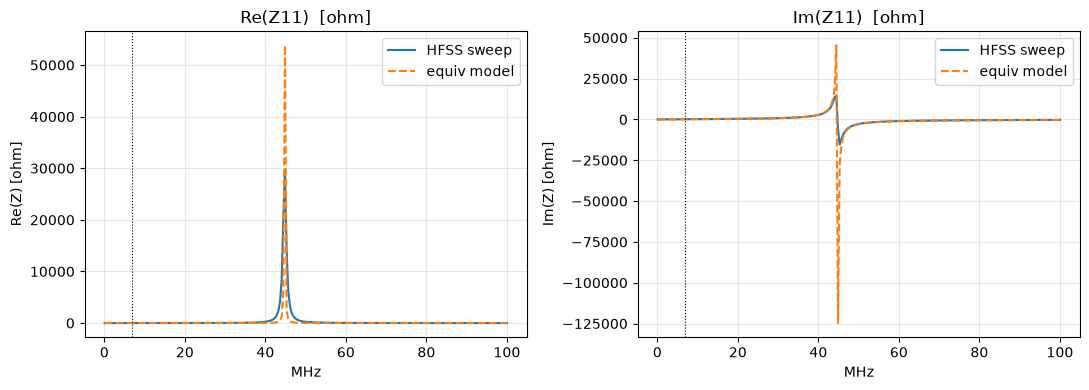

@ 6.79 MHz   Re: HFSS(sweep)=0.0938  model=0.0937  (COIL target=0.0936)
@ 6.79 MHz   Im: HFSS(sweep)=100.8068  model=100.8071  (COIL target=100.6200)


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(fr/1e6, reS, label='HFSS sweep')
ax[0].plot(fr/1e6, Zm.real, '--', label='equiv model')
ax[0].axvline(f0/1e6, color='k', ls=':', lw=0.8)
ax[0].set_title('Re(Z11)  [ohm]'); ax[0].set_xlabel('MHz'); ax[0].set_ylabel('Re(Z) [ohm]')
ax[0].legend(); ax[0].grid(True, alpha=.3)

ax[1].plot(fr/1e6, imS, label='HFSS sweep')
ax[1].plot(fr/1e6, Zm.imag, '--', label='equiv model')
ax[1].axvline(f0/1e6, color='k', ls=':', lw=0.8)
ax[1].set_title('Im(Z11)  [ohm]'); ax[1].set_xlabel('MHz'); ax[1].set_ylabel('Im(Z) [ohm]')
ax[1].legend(); ax[1].grid(True, alpha=.3)

plt.tight_layout(); plt.show()

# 6.78 MHz 단일점에서의 일치 확인
i0 = int(np.argmin(np.abs(fr - f0)))
print(f'@ {fr[i0]/1e6:.2f} MHz   Re: HFSS(sweep)={reS[i0]:.4f}  model={Zm.real[i0]:.4f}  (COIL target={Z11.real:.4f})')
print(f'@ {fr[i0]/1e6:.2f} MHz   Im: HFSS(sweep)={imS[i0]:.4f}  model={Zm.imag[i0]:.4f}  (COIL target={Z11.imag:.4f})')